In [41]:
import pandas as pd
import plotnine as pn
import numpy as np
from scipy.stats import beta
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)
import itables.options as opt
opt.lengthMenu = [10, 20, 50, 100]
opt.pageLength = 20   # in newer versions; otherwise use show(..., pageLength=20)



In [42]:
import sys
sys.path.append("../")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *


In [43]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")


# Aberrant Expression

In [44]:
py_or_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants.csv")

py_or_res_all = pd.merge(py_or_res_all, sa, left_on="sampleID", right_on="pid")
py_or_res_all = pd.merge(py_or_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID", how="left")

py_or_res_aberrant = py_or_res_all[py_or_res_all["padjust"] <= 0.05]
py_or_res_aberrant = py_or_res_aberrant.merge(gene_annot_dt[["gene_name", "gene_id"]], left_on="geneID", right_on="gene_id", how="left").drop(columns="gene_id")

py_or_res_aberrant = py_or_res_aberrant.rename(columns={"gene_name_y": "gene_name"})

In [45]:
print(py_or_res_aberrant[~py_or_res_aberrant["promoterAI_snv"].notna()].shape)
py_or_res_aberrant[py_or_res_aberrant["promoterAI_snv"].notna()]["IMPACT_snv"].value_counts()


(70533, 79)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 70533 rows containing non-finite values.


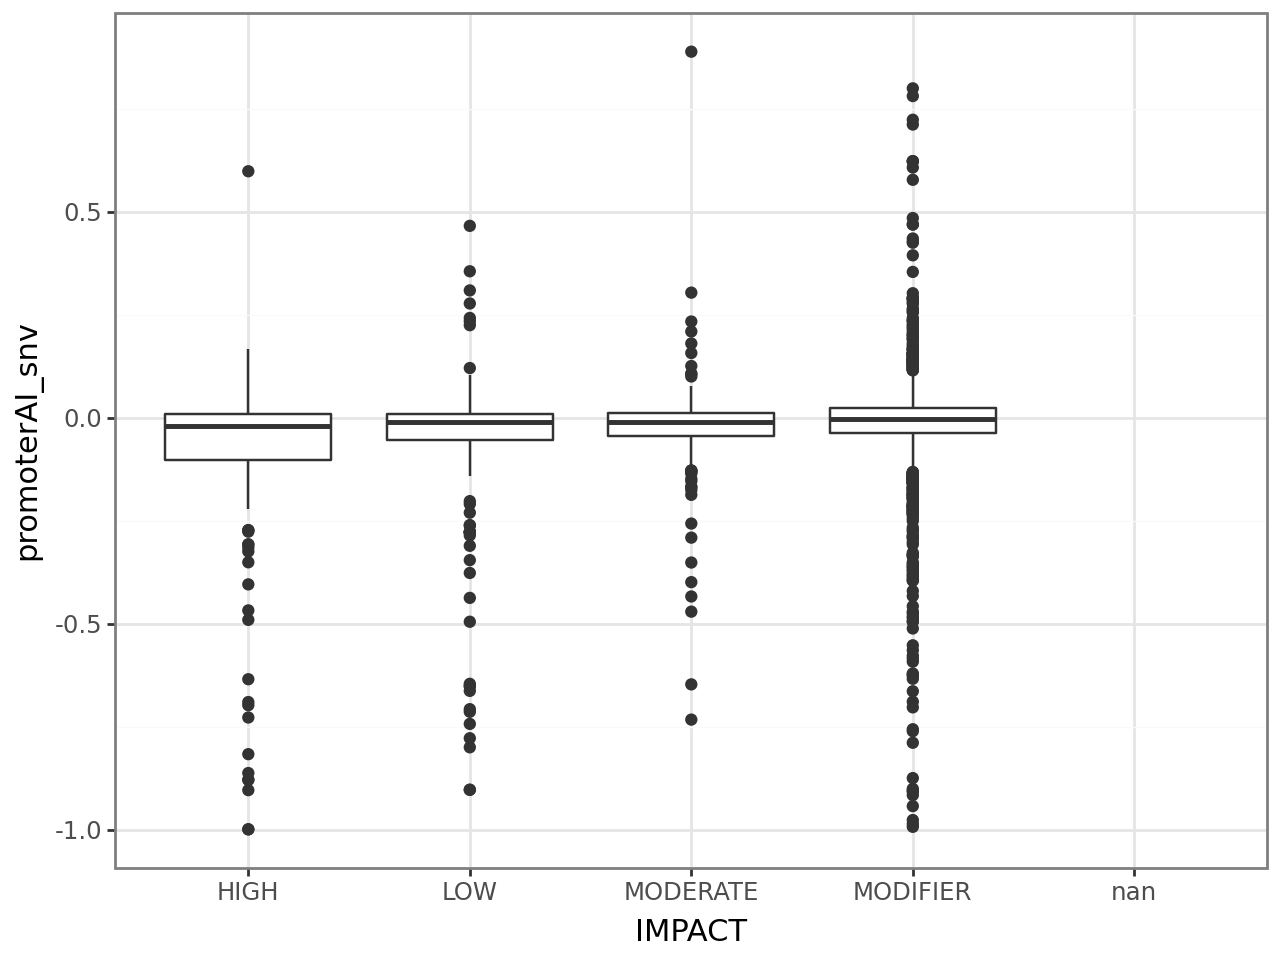

In [11]:
p1 = (pn.ggplot(py_or_res_aberrant) +
      pn.geom_boxplot(pn.aes(x="IMPACT", y="promoterAI_snv")) +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 30397 rows containing non-finite values.


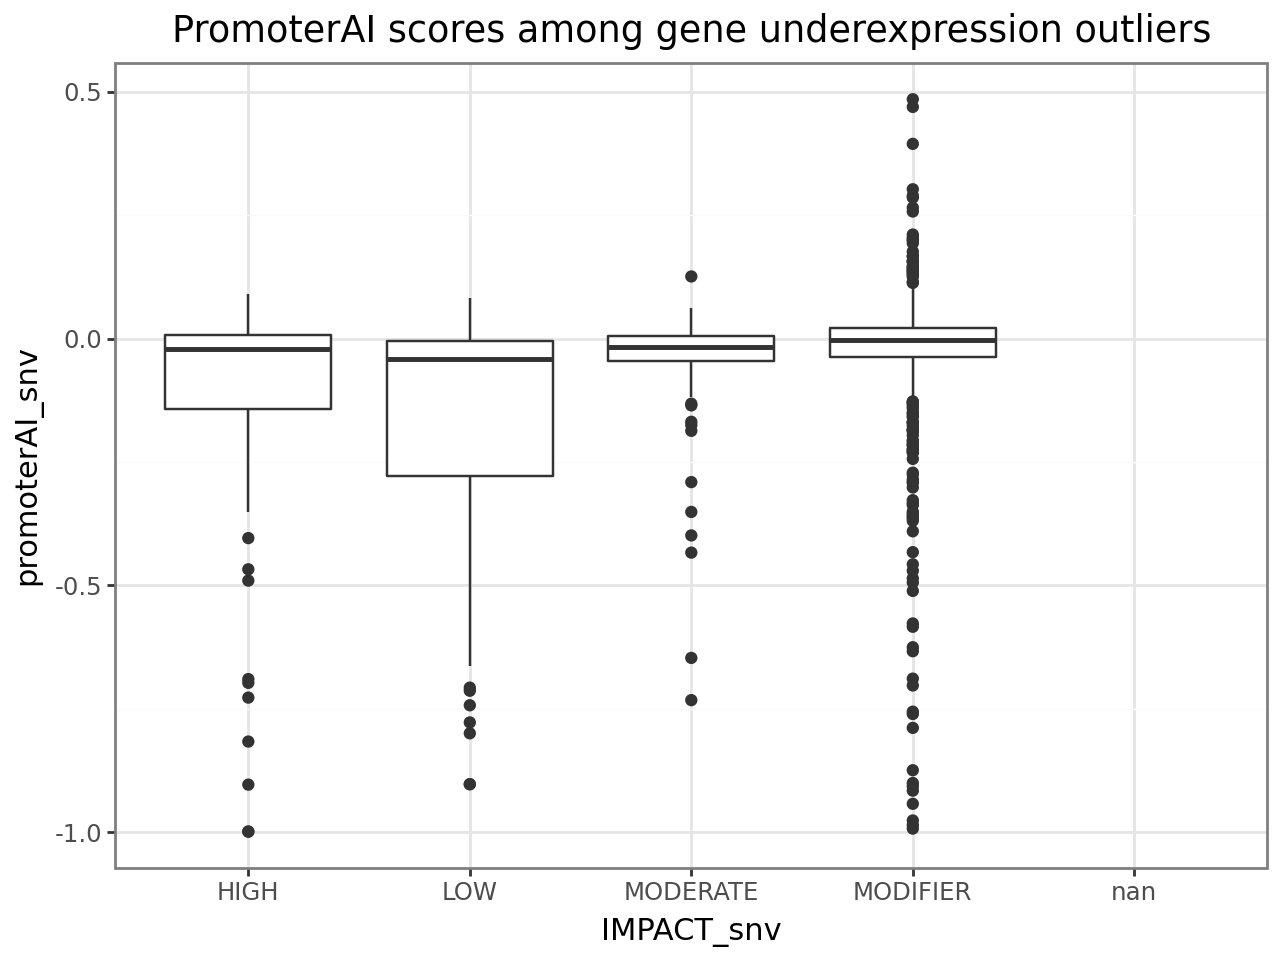

In [21]:
p1 = (pn.ggplot(py_or_res_aberrant[py_or_res_aberrant["Outlier status"] == "Underexpression"]) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among gene underexpression outliers") +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 40136 rows containing non-finite values.


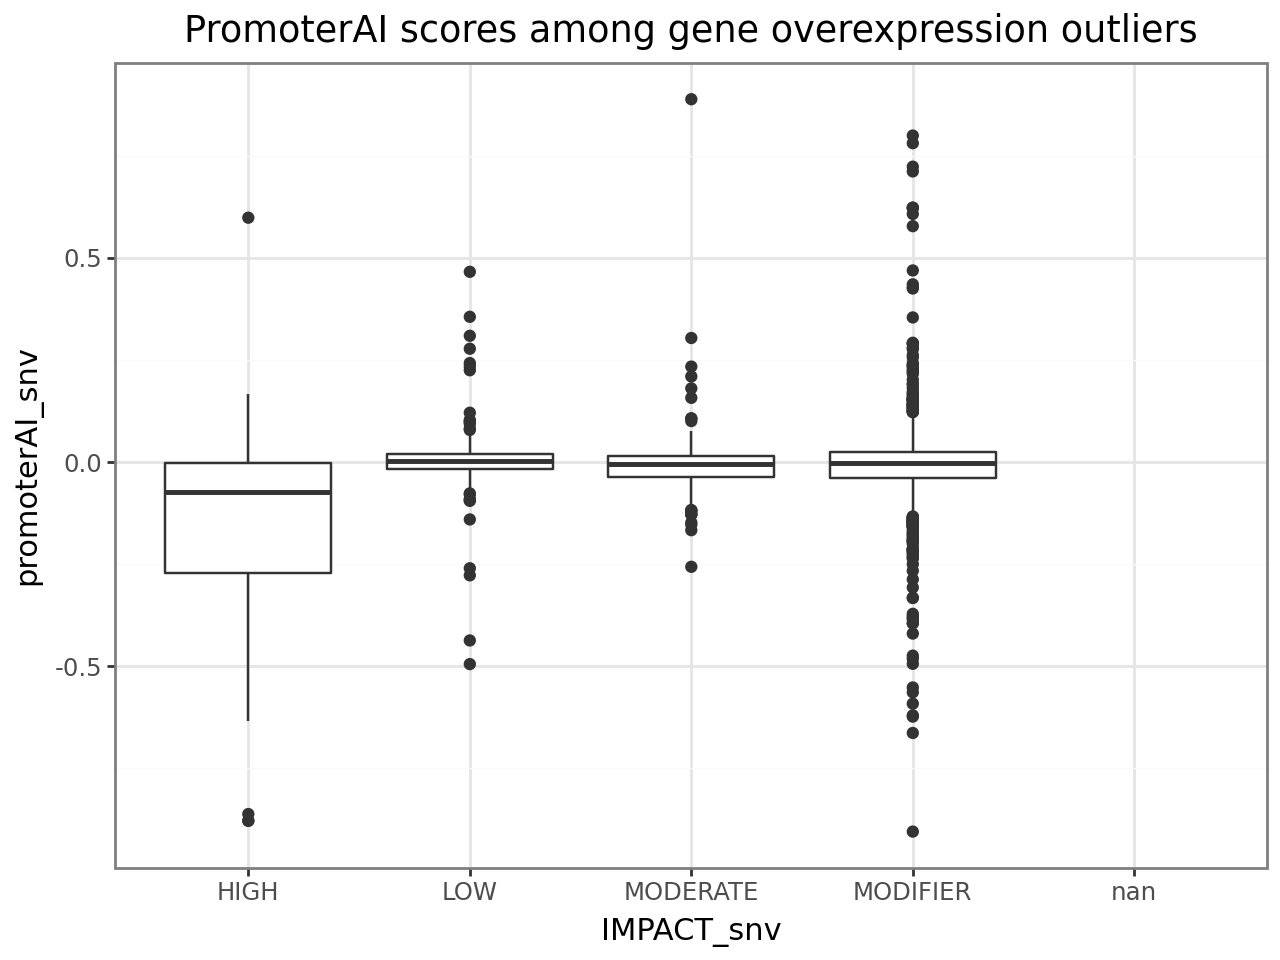

In [20]:
p1 = (pn.ggplot(py_or_res_aberrant[py_or_res_aberrant["Outlier status"] == "Overexpression"]) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among gene overexpression outliers") +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 70533 rows containing non-finite values.


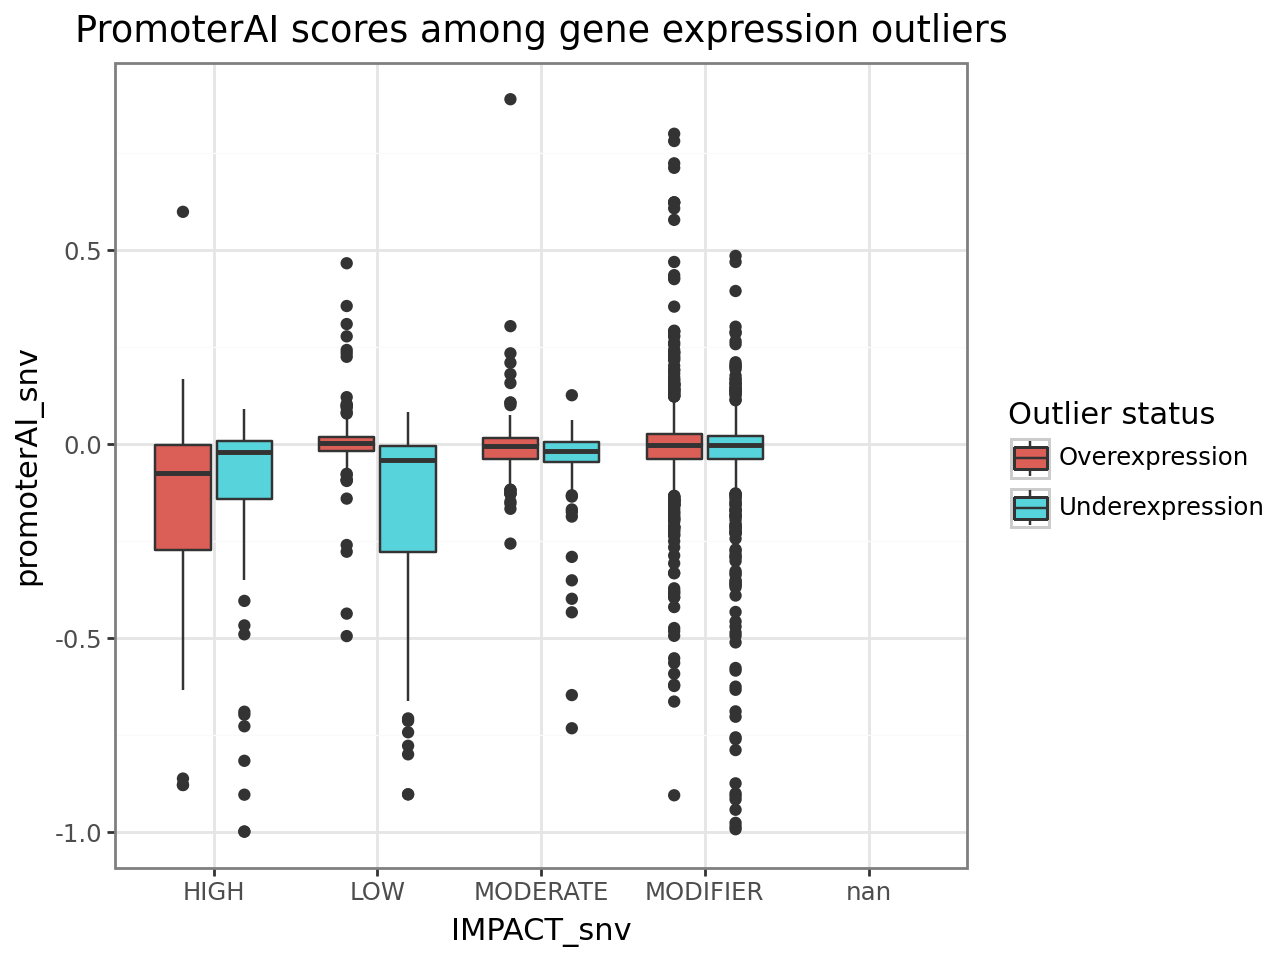

In [73]:
p1 = (pn.ggplot(py_or_res_aberrant) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv", fill="Outlier status")) +
      pn.labs(title="PromoterAI scores among gene expression outliers") +
      pn.theme_bw()
     )
p1

In [27]:
interestings = py_or_res_aberrant[ (py_or_res_aberrant["promoterAI_snv"].notna()) & (py_or_res_aberrant["promoterAI_snv"] <= -0.1) &(py_or_res_aberrant["predisposition_gene"] == True) ]
interestings[["sampleID", "gene_name", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status"]]

In [52]:
interestings_2 = py_or_res_aberrant[ (py_or_res_aberrant["promoterAI_snv"].notna()) & (py_or_res_aberrant["promoterAI_snv"] >= 0.1)]
interestings_2[["sampleID", "gene_name", "promoterAI_snv", "IMPACT_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status", "Consequence_snv"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [46]:
py_or_res_aberrant

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Aberrant proteomics

In [54]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants.csv")
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all = pd.merge(pr_res_all, sa, left_on="sampleID", right_on="pid")
pr_res_aberrant = pr_res_all[pr_res_all["padjust"] <= 0.1]


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 5008 rows containing non-finite values.


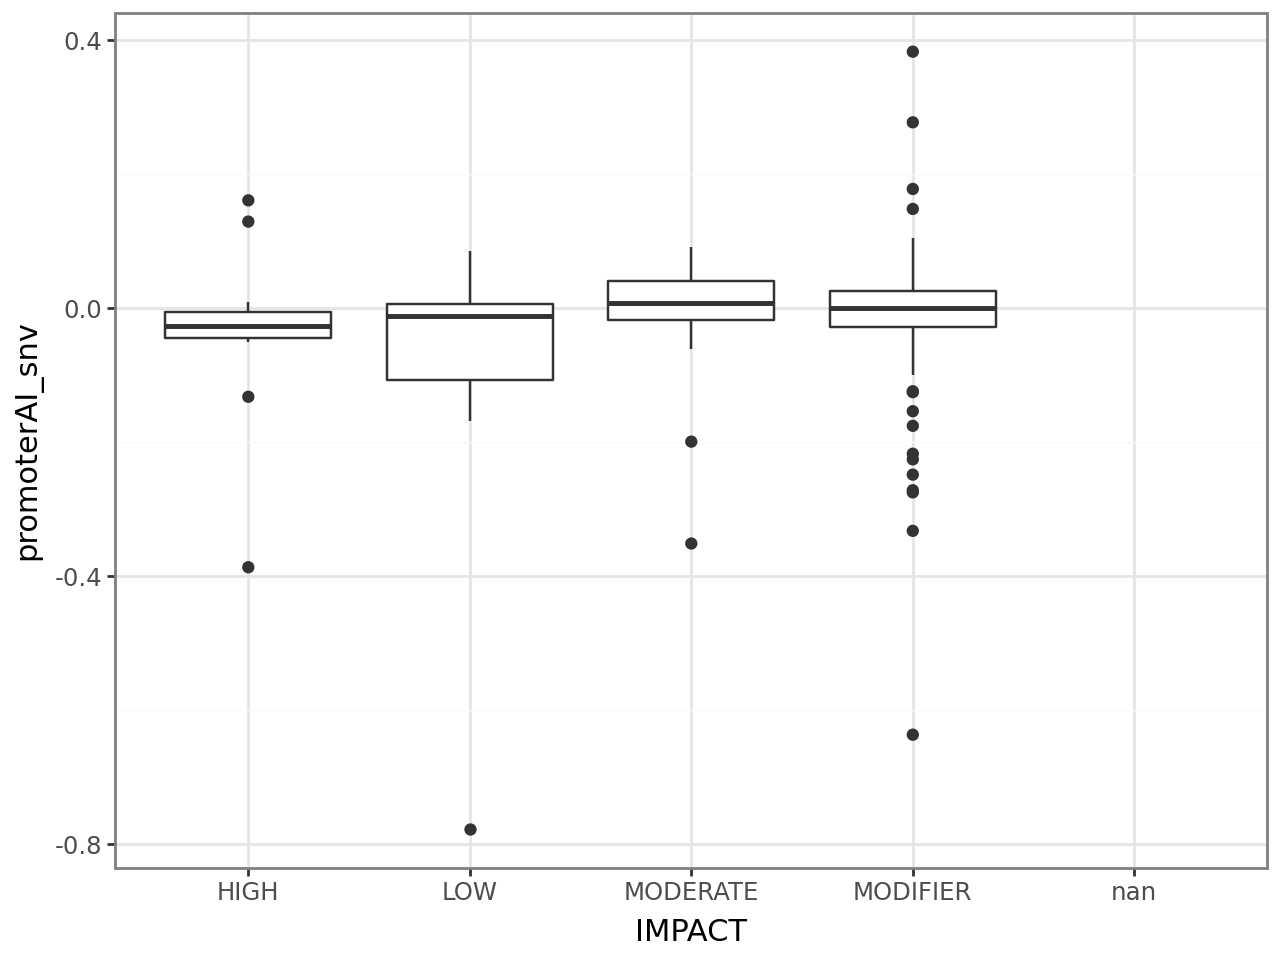

In [59]:
p1 = (pn.ggplot(pr_res_aberrant) +
      pn.geom_boxplot(pn.aes(x="IMPACT", y="promoterAI_snv")) +
      pn.theme_bw()
     )
p1


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 3012 rows containing non-finite values.


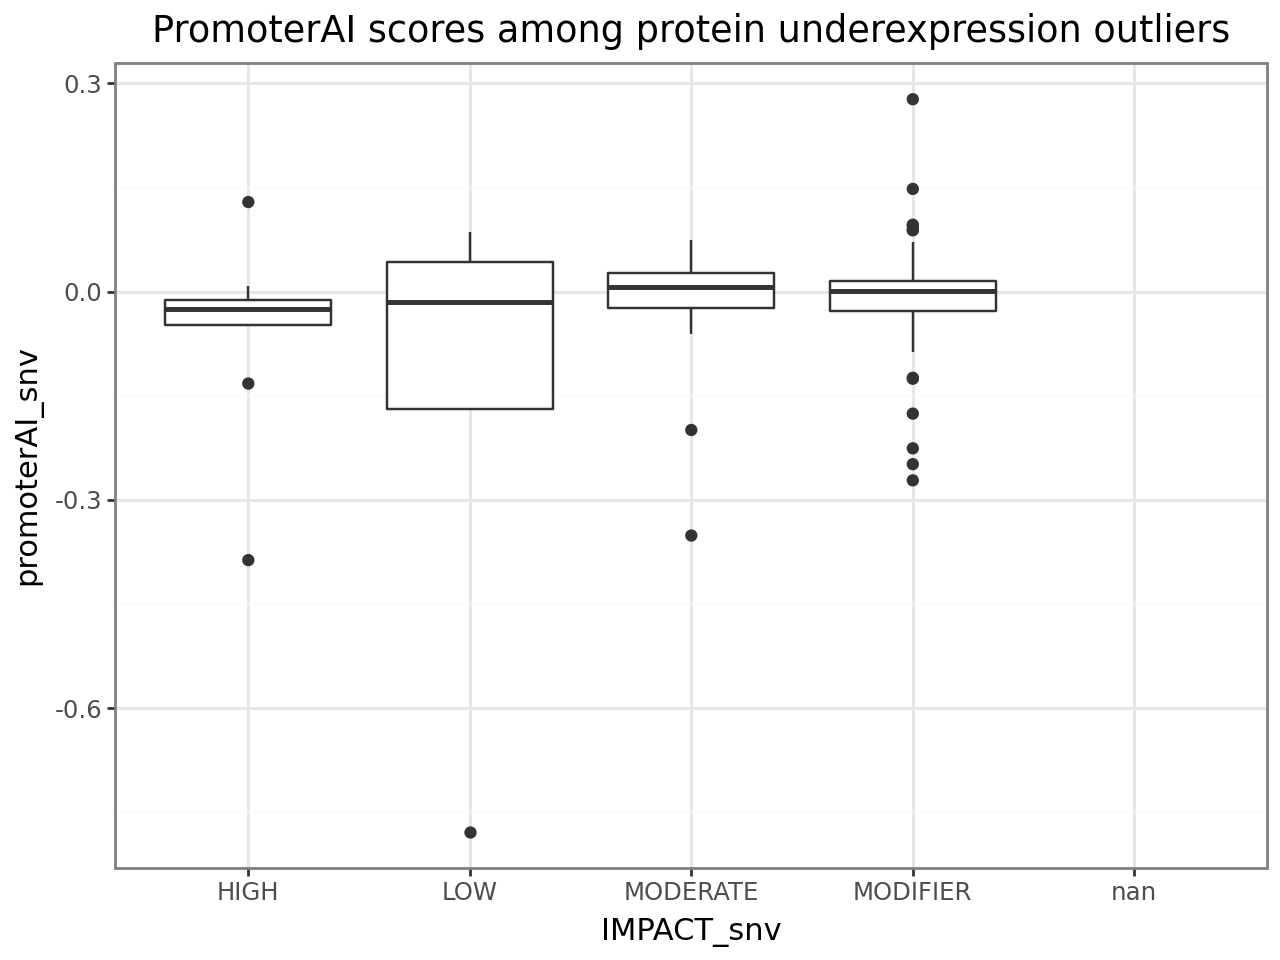

In [63]:
p1 = (pn.ggplot(pr_res_aberrant[pr_res_aberrant["Outlier status"] == "Underexpression"]) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among protein underexpression outliers") +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 1996 rows containing non-finite values.


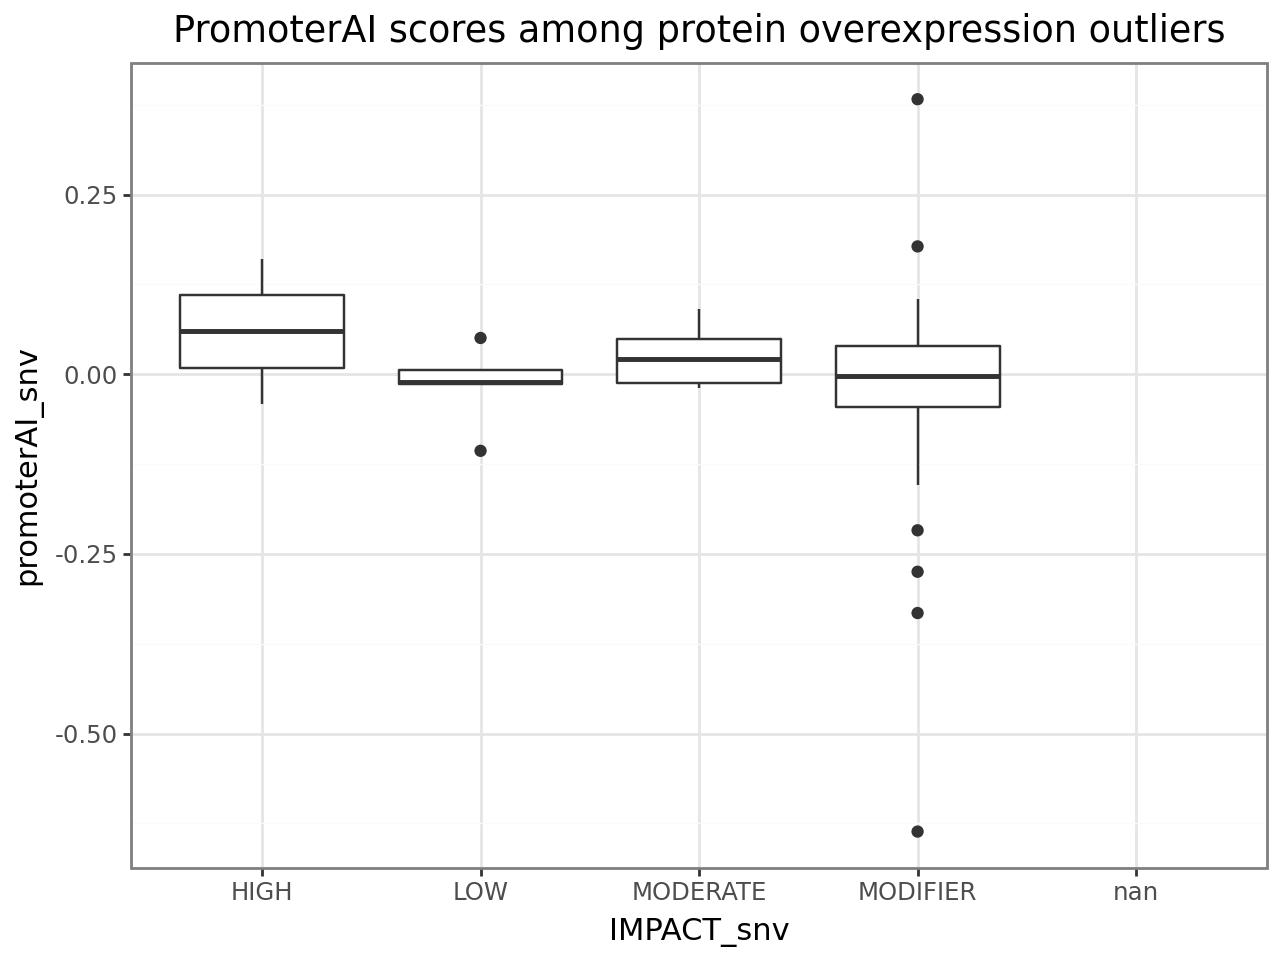

In [64]:
p1 = (pn.ggplot(pr_res_aberrant[pr_res_aberrant["Outlier status"] == "Overexpression"]) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among protein overexpression outliers") +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 5008 rows containing non-finite values.


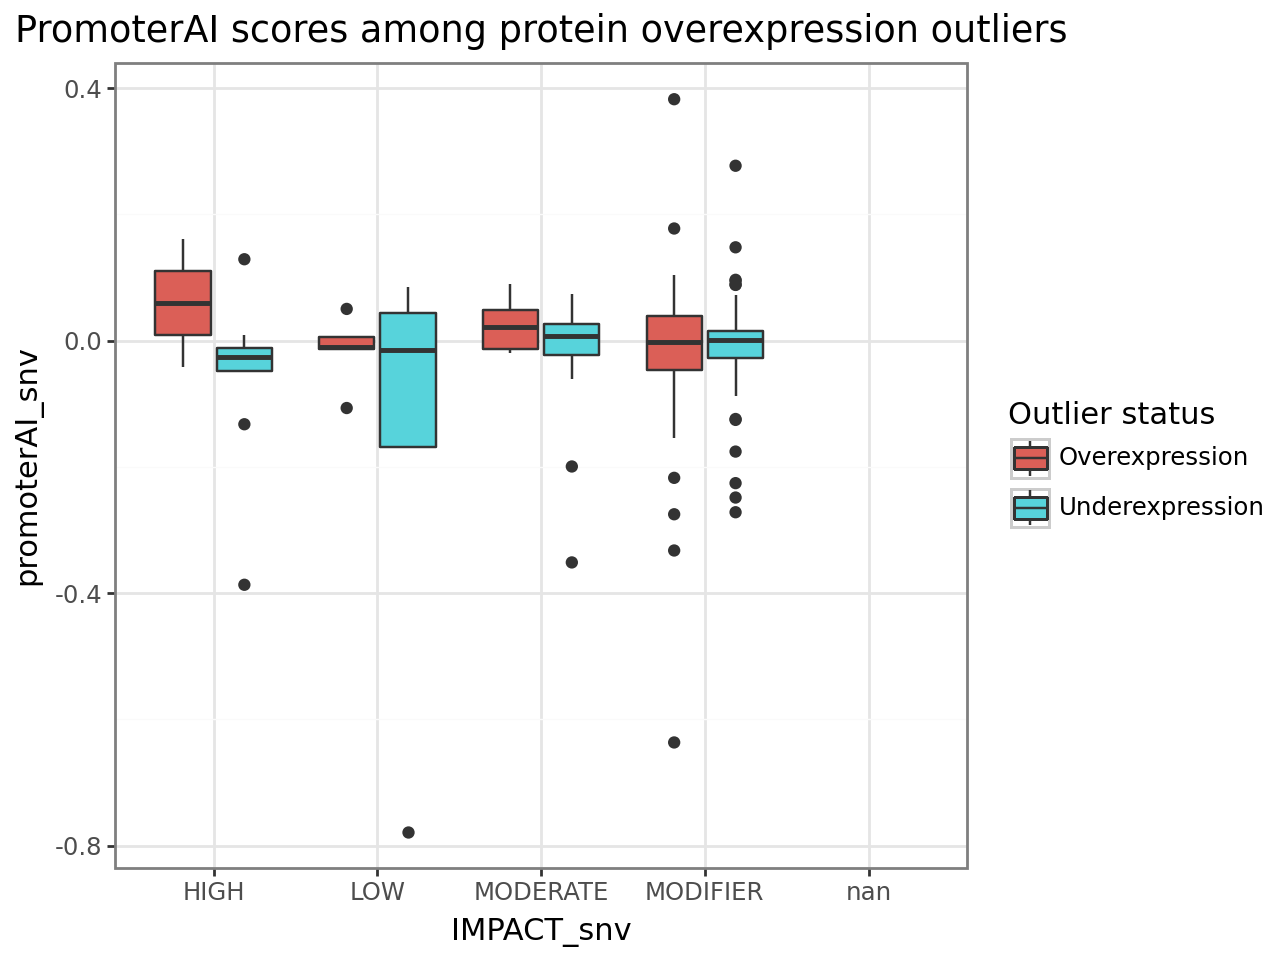

In [71]:
p1 = (pn.ggplot(pr_res_aberrant) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv", fill="Outlier status")) +
      pn.labs(title="PromoterAI scores among protein overexpression outliers") +
      pn.theme_bw()
     )
p1

In [74]:
interestings = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] <= -0.1) &(pr_res_aberrant["predisposition_gene"] == True) ]
interestings[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [75]:
interestings = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] >= 0.1) &(pr_res_aberrant["predisposition_gene"] == True) ]
interestings[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
interestings_2 = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] >= 0.1)]
interestings_2[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status", "Consequence_snv"]]

In [82]:
interestings_2 = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] <= -0.1) &  (pr_res_aberrant["Outlier status"] == "Underexpression")]
interestings_2[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status", "Consequence_snv"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# splicing outliers

In [15]:
splicing_res_outliers = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
splicing_res_outliers = pd.merge(splicing_res_outliers, sa, left_on="sampleID", right_on="pid")


In [16]:
splicing_res_outliers = pd.merge(splicing_res_outliers, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID", how="left")


In [40]:
print(splicing_res_outliers[~splicing_res_outliers["promoterAI_snv"].notna()].shape)
splicing_res_outliers[splicing_res_outliers["promoterAI_snv"].notna()]["IMPACT_snv"].value_counts()


(398784, 95)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 398784 rows containing non-finite values.


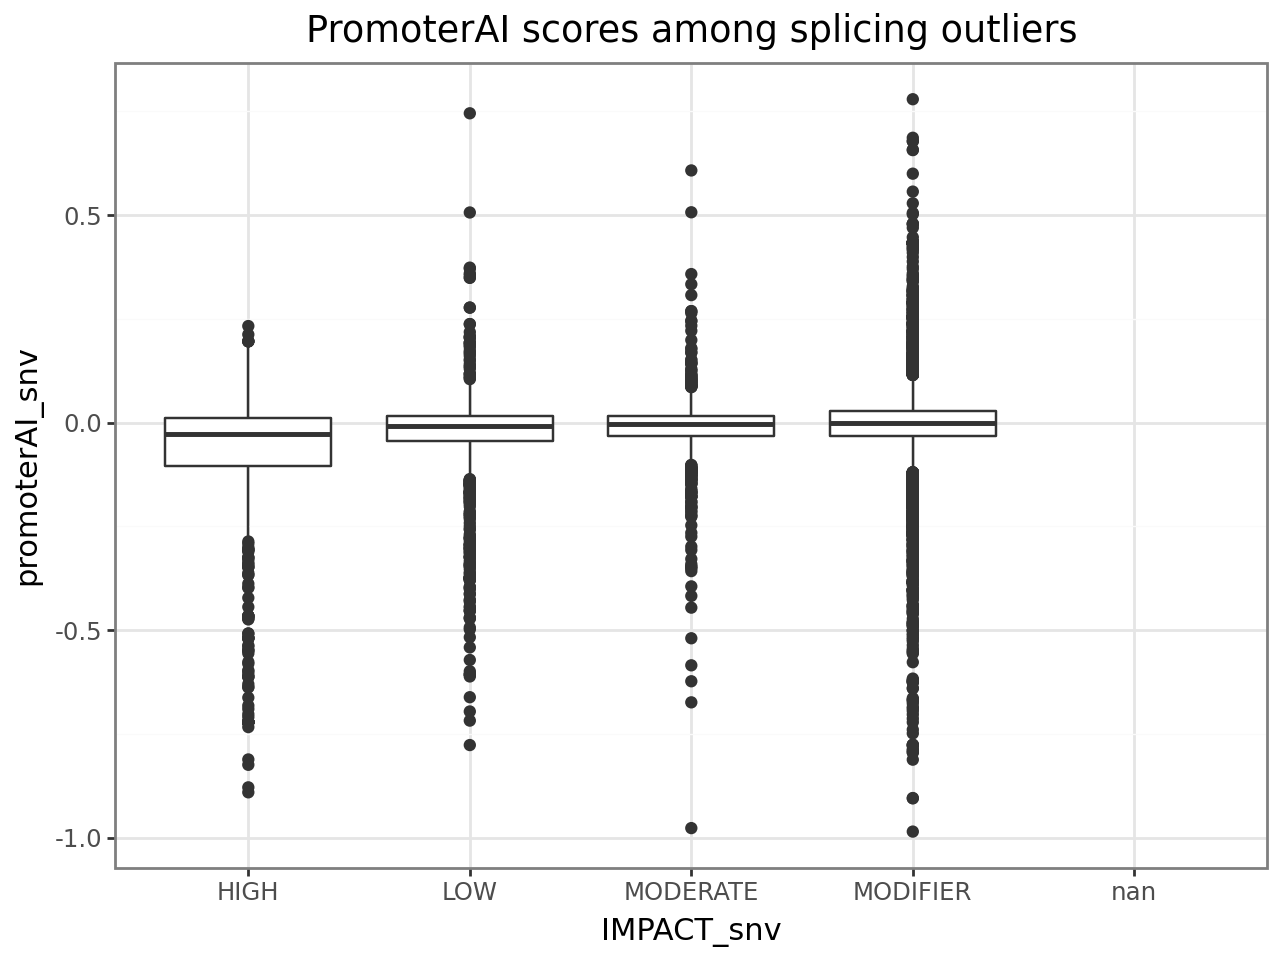

In [11]:
p1 = (pn.ggplot(splicing_res_outliers) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among splicing outliers") +
      pn.theme_bw()
     )
p1

In [24]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] <= -0.1) &(splicing_res_outliers["predisposition_gene"] == True) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [25]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] >= 0.1) &(splicing_res_outliers["predisposition_gene"] == True) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [28]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] <= -0.1) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [29]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] >= 0.1) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [46]:
splicing_res_outliers[

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
